# Session 0 — How LLMs Work: A Visual Tour

> **When to use this notebook:** Run it as a 20-minute visual warm-up before Session 1 (Sat 20 Jun),
> or share it with students the night before so everyone arrives with the same mental model.

## Learning Objectives
After this notebook you will be able to:
- Explain what a **token** is and count tokens in any text
- Describe LLMs as **next-token predictors** operating over probability distributions
- Understand how **temperature** controls creativity vs precision
- Interpret the **context window** diagram you will see throughout the course
- Recognise that different **models** trade cost for capability

## Agenda (~20 min)
| # | Topic | Time |
|---|-------|------|
| 1 | Tokenisation | 4 min |
| 2 | Next-Token Prediction & Logprobs | 4 min |
| 3 | Temperature & Sampling | 4 min |
| 4 | Context Window | 3 min |
| 5 | Streaming | 2 min |
| 6 | Model Landscape (Cost vs Capability) | 3 min |

In [1]:
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import HTML, display
import tiktoken
from dotenv import load_dotenv

sys.path.insert(0, '../..')
from utils.config import MODELS, get_client

load_dotenv('../../.env')
MOCK  = os.getenv('MOCK', '0') == '1'
MODEL = MODELS['chat']

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

try:
    client = get_client() if not MOCK else None
    print(f'✓ Client ready  —  default model: {MODEL}')
    if MOCK:
        print('  (MOCK mode: API calls return canned responses)')
except ValueError as exc:
    print(f'✗ {exc}')
    client = None

✓ Client ready  —  default model: gpt-5.4-mini


---
## Part 1 — What is a Token?

An LLM never sees *characters* — it sees **tokens**.
A token is roughly 4 characters of English text, but it varies by language and content type.

**Why it matters:**
- The API bills you per token (not per character or word).
- The context window limit is measured in tokens.
- Rare words and non-Latin scripts use *more* tokens per word → higher cost and fewer turns per dollar.

We use **`tiktoken`** — OpenAI's tokeniser library — to see exactly how text is split.

In [2]:
# ── Colour-coded token renderer ──────────────────────────────────────────────
PALETTE = [
    '#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A',
    '#98D8C8', '#DDA0DD', '#90EE90', '#FFB6C1',
    '#87CEEB', '#F0E68C', '#C8A2C8', '#FFD700',
]

# gpt-5.x uses the same o200k_base encoding family as gpt-4o.
# tiktoken may not yet know 'gpt-5.4-mini' by name, so we fall back explicitly.
try:
    enc = tiktoken.encoding_for_model('gpt-4o')
except KeyError:
    enc = tiktoken.get_encoding('o200k_base')


def show_tokens(text: str, title: str = '') -> int:
    '''Render colour-coded tokens inline and return token count.'''
    token_ids = enc.encode(text)
    parts = []
    if title:
        parts.append(f'<b style="font-family:sans-serif;font-size:1em">{title}</b><br>')
    for i, tid in enumerate(token_ids):
        color = PALETTE[i % len(PALETTE)]
        raw   = enc.decode([tid])
        safe  = raw.replace('&', '&amp;').replace('<', '&lt;').replace('>', '&gt;')
        shown = safe.replace(' ', '·').replace('\n', '↵')
        parts.append(
            f'<span style="background:{color};padding:2px 7px;margin:1px 2px;'
            f'border-radius:4px;font-family:monospace;font-size:0.95em">'
            f'{shown}'
            f'<sup style="font-size:0.6em;color:#444"> {tid}</sup>'
            f'</span>'
        )
    parts.append(
        f'<br><small style="font-family:sans-serif">'
        f'→ <b>{len(token_ids)}</b> tokens for {len(text)} characters'
        f'</small><br><br>'
    )
    display(HTML(''.join(parts)))
    return len(token_ids)


print('Each coloured box = one token.  Subscript = token ID.\n')
show_tokens('Hello, world! How are you today?',                title='English sentence')
show_tokens('def fibonacci(n):\n    return n if n <= 1 else fibonacci(n-1) + fibonacci(n-2)',
            title='Python code')
show_tokens('\u0928\u092e\u0938\u094d\u0924\u0947 \u0926\u0941\u0928\u093f\u092f\u093e',    title='Hindi: "Hello World" (नमस्ते दुनिया)')

Each coloured box = one token.  Subscript = token ID.



5

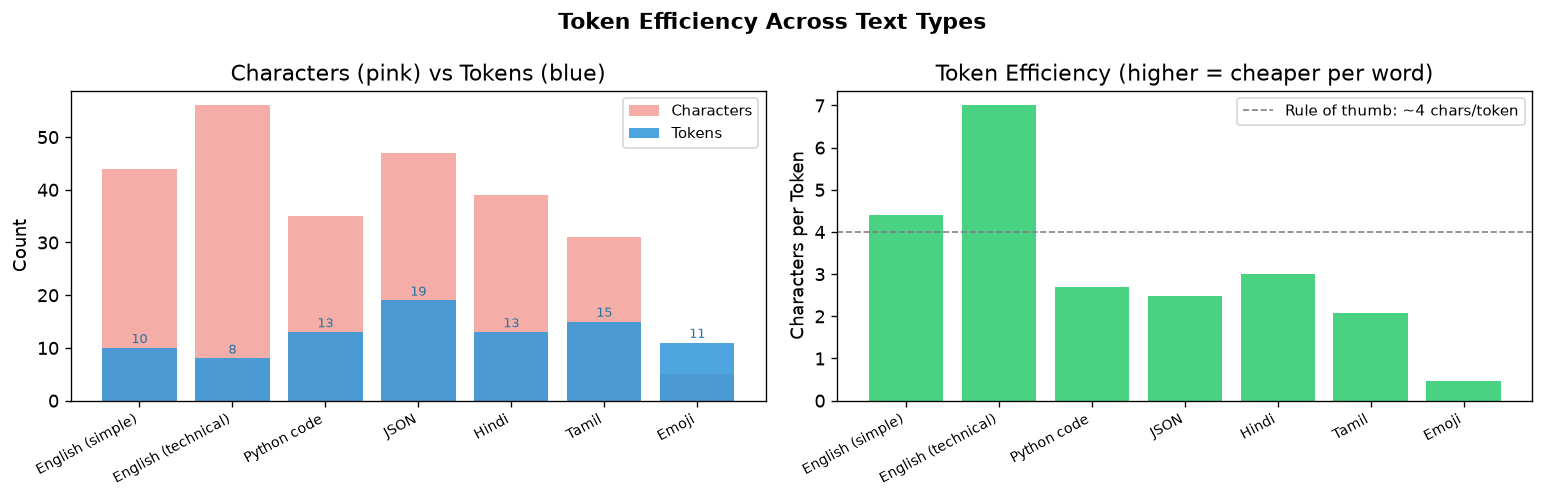

In [3]:
# ── Token-count comparison across text types ─────────────────────────────────
samples = {
    'English (simple)':     'The quick brown fox jumps over the lazy dog.',
    'English (technical)':  'Transformer architecture uses self-attention mechanisms.',
    'Python code':          'for i in range(10):\n    print(i**2)',
    'JSON':                 '{"name": "Alice", "age": 30, "city": "Chennai"}',
    'Hindi':                'कृत्रिम बुद्धिमत्ता का भविष्य उज्जवल है',
    'Tamil':                'செயற்கை நுண்ணறிவு தொழில்நுட்பம்',
    'Emoji':                '🚀🤖🧠💡🌍',
}

chars  = [len(t)               for t in samples.values()]
tokens = [len(enc.encode(t))   for t in samples.values()]
ratios = [c / t                for c, t in zip(chars, tokens)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
x = np.arange(len(samples))

# Left: tokens vs characters
axes[0].bar(x, chars,  color='#e74c3c', alpha=0.45, label='Characters')
axes[0].bar(x, tokens, color='#3498db', alpha=0.88, label='Tokens')
axes[0].set_xticks(x)
axes[0].set_xticklabels(list(samples.keys()), rotation=28, ha='right', fontsize=8.5)
axes[0].set_ylabel('Count')
axes[0].set_title('Characters (pink) vs Tokens (blue)')
axes[0].legend(fontsize=9)
for xi, (c, t) in enumerate(zip(chars, tokens)):
    axes[0].text(xi, t + 0.3, str(t), ha='center', va='bottom', fontsize=8, color='#2471a3')

# Right: chars-per-token ratio
axes[1].bar(x, ratios, color='#2ecc71', alpha=0.88)
axes[1].axhline(4, color='gray', linestyle='--', linewidth=1, label='Rule of thumb: ~4 chars/token')
axes[1].set_xticks(x)
axes[1].set_xticklabels(list(samples.keys()), rotation=28, ha='right', fontsize=8.5)
axes[1].set_ylabel('Characters per Token')
axes[1].set_title('Token Efficiency (higher = cheaper per word)')
axes[1].legend(fontsize=9)

plt.suptitle('Token Efficiency Across Text Types', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Exercise 1:** How many tokens is your full name in English? What about in your native language?
> Replace the strings below and run the cell.

In [4]:
# your turn:
my_name_english = 'Chandrakanth'
my_name_native  = 'சந்திரகாந்த்'   # replace with your language

# --- live-code below ---

show_tokens(my_name_english)
show_tokens(my_name_native)


5

---
## Part 2 — The Prediction Machine

At its core, an LLM is a **next-token predictor**.

Given a sequence of tokens, it outputs a **probability distribution** over its entire vocabulary
(~100 000 tokens for gpt-5.x). Sampling from this distribution gives the next token. Repeat —
and you have text generation.

The API exposes these raw probabilities via `logprobs=True`:

```
logprob = log(probability)   →   always ≤ 0
np.exp(logprob)              →   converts back to probability  (0 – 1)
```

*Log-probabilities are used because raw probabilities get astronomically small —
log space keeps numbers tractable.*

In [5]:
# ── Fetch the top-5 next-token candidates ────────────────────────────────────
# Ambiguous prompt → richer probability distribution (more interesting to visualise).
PROMPT = 'My favourite programming language is'

if MOCK or client is None:
    class _LP:
        def __init__(self, t, lp): self.token = t; self.logprob = lp
    top_lps      = [_LP('Nice',  -0.53), _LP('It',    -1.79), _LP('Looks', -2.03),
                    _LP('What',  -2.78), _LP('\u2026', -4.27)]
    chosen_token = 'Nice'
else:
    response = client.chat.completions.create(
        model=MODEL,
        messages=[{'role': 'user', 'content': PROMPT}],
        max_completion_tokens=5,   # gpt-5.x requires >= 5; we only read content[0]
        logprobs=True,
        top_logprobs=5,
    )
    first_tok    = response.choices[0].logprobs.content[0]
    top_lps      = first_tok.top_logprobs
    chosen_token = first_tok.token       # first generated token (highest-prob)

print(f'Prompt : "{PROMPT}"')
print(f'Chosen : "{chosen_token.strip()}"  (highest probability)\n')
print(f'{"Token":<22} {"Logprob":>10} {"Probability":>13}')
print('─' * 47)
for lp in top_lps:
    prob = float(np.exp(lp.logprob))
    print(f'{repr(lp.token):<22} {lp.logprob:>10.3f} {prob:>13.4f}')

Prompt : "My favourite programming language is"
Chosen : "Nice"  (highest probability)

Token                     Logprob   Probability
───────────────────────────────────────────────
'Nice'                     -0.058        0.9432
'It'                       -4.308        0.0135
'Looks'                    -4.558        0.0105
'…'                        -4.558        0.0105
'What'                     -5.558        0.0039


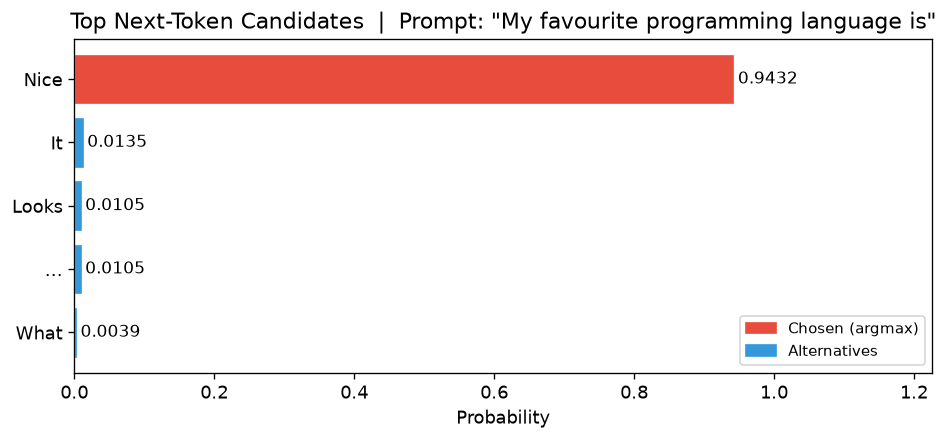

The taller the bar, the more likely that token. A flat distribution = more creative/uncertain.
Try changing PROMPT above to something unambiguous (e.g. "2 + 2 =") and rerun.


In [6]:
# ── Visualise the probability distribution ───────────────────────────────────
tok_labels = [lp.token.strip() or repr(lp.token) for lp in top_lps]
probs      = [float(np.exp(lp.logprob))           for lp in top_lps]
bar_colors = ['#e74c3c' if lp.token == chosen_token else '#3498db' for lp in top_lps]

fig, ax = plt.subplots(figsize=(8, 3.8))
bars = ax.barh(tok_labels[::-1], probs[::-1],
               color=bar_colors[::-1], edgecolor='white', linewidth=0.8)

for bar, prob in zip(bars, probs[::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{prob:.4f}', va='center', fontsize=10)

ax.set_xlabel('Probability')
ax.set_xlim(0, max(probs) * 1.3)
ax.set_title(f'Top Next-Token Candidates  |  Prompt: "{PROMPT}"')

patch_chosen = mpatches.Patch(color='#e74c3c', label='Chosen (argmax)')
patch_alt    = mpatches.Patch(color='#3498db', label='Alternatives')
ax.legend(handles=[patch_chosen, patch_alt], loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

print('The taller the bar, the more likely that token. A flat distribution = more creative/uncertain.')
print('Try changing PROMPT above to something unambiguous (e.g. "2 + 2 =") and rerun.')

---
## Part 3 — Temperature: Creativity vs Precision

The model's raw output is a vector of **logits** (one score per vocabulary token).
**Softmax** converts logits → probabilities.

The `temperature` parameter **divides** every logit before softmax:

| Temperature | Effect | Use case |
|-------------|--------|----------|
| `0` | Always picks argmax (greedy) | Facts, maths, code |
| `0.1 – 0.5` | Near-deterministic, focused | Classification, extraction |
| `1.0` | Default; logits unchanged | General use |
| `1.5 – 2.0` | Flatter distribution → surprising output | Brainstorming, creative writing |

> Rule of thumb: **`temperature=0`** for correctness; **`temperature=0.7–1.2`** for creativity.

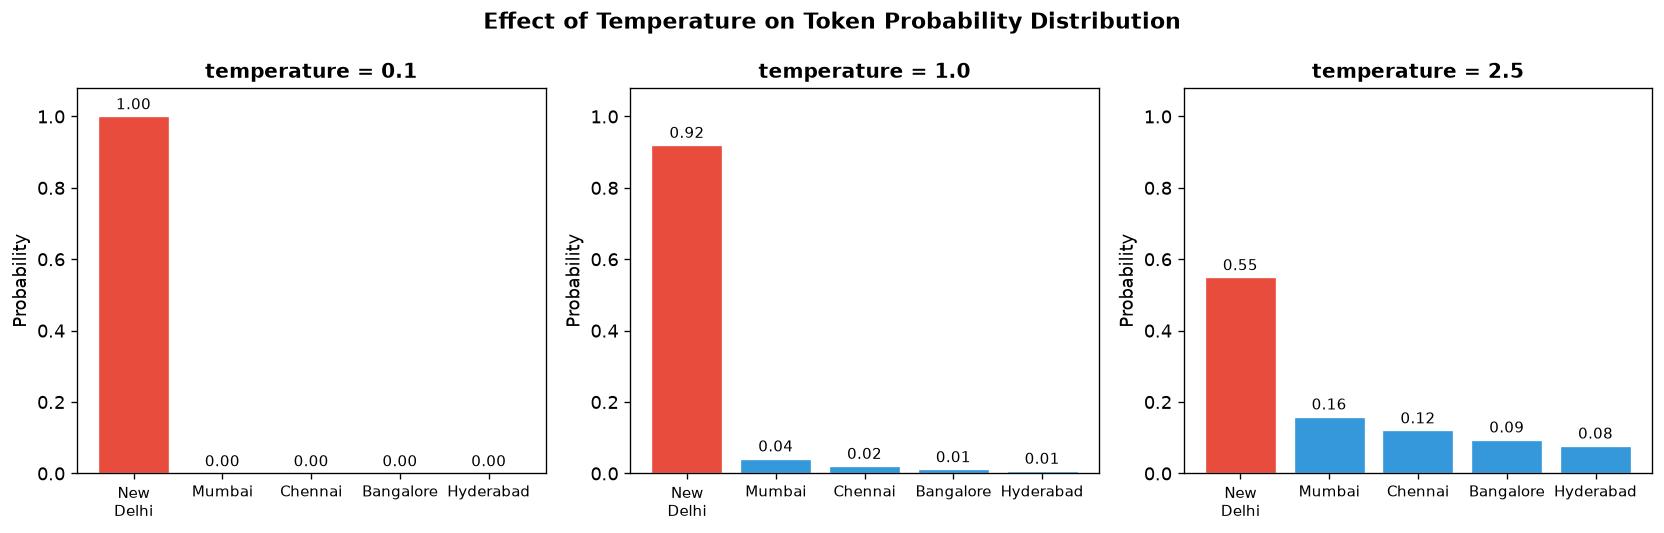

temp=0.1 → near-certain choice (New Delhi)
temp=2.5 → flatter distribution → the model might surprise you


In [7]:
# ── Static visualisation — no API call needed ────────────────────────────────
def softmax(logits, temperature=1.0):
    scaled = np.array(logits, dtype=float) / max(temperature, 1e-9)
    e = np.exp(scaled - scaled.max())
    return e / e.sum()

# Hypothetical logits for "next word after 'The capital of India is'"
candidate_tokens = ['New\nDelhi', 'Mumbai', 'Chennai', 'Bangalore', 'Hyderabad']
raw_logits       = np.array([5.2, 2.1, 1.4, 0.8, 0.3])

temperatures = [0.1, 1.0, 2.5]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=False)

for ax, temp in zip(axes, temperatures):
    probs      = softmax(raw_logits, temp)
    bar_colors = ['#e74c3c' if p == probs.max() else '#3498db' for p in probs]
    ax.bar(candidate_tokens, probs, color=bar_colors, edgecolor='white', linewidth=0.8)
    ax.set_title(f'temperature = {temp}', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.08)
    ax.set_ylabel('Probability')
    ax.tick_params(axis='x', labelsize=9)
    for i, p in enumerate(probs):
        ax.text(i, p + 0.02, f'{p:.2f}', ha='center', fontsize=9)

fig.suptitle(
    'Effect of Temperature on Token Probability Distribution',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

print('temp=0.1 → near-certain choice (New Delhi)')
print('temp=2.5 → flatter distribution → the model might surprise you')

In [8]:
# ── Live demo: same prompt, three temperatures ───────────────────────────────
prompt = 'Complete this sentence in exactly five words: The best way to learn AI is'

for temp in [0.1, 1.0, 1.8]:
    if MOCK or client is None:
        reply = f'[MOCK] response at temp={temp}'
    else:
        resp = client.chat.completions.create(
            model=MODEL,
            messages=[{'role': 'user', 'content': prompt}],
            temperature=temp,
            max_completion_tokens=20,
        )
        reply = resp.choices[0].message.content.strip()
    print(f'  temp={temp:<4}  →  {reply}')

  temp=0.1   →  to build, experiment, and iterate.


  temp=1.0   →  by building real projects daily


  temp=1.8   →  to build, experiment, and iterate.


> **Exercise 2:** Change `prompt` above to a creative task (e.g., *"Write a one-line tagline for a chai startup"*).
> Run it at `temperature=0.1` and `temperature=1.8`. What do you notice?

In [9]:
# your turn:
creative_prompt = 'Write a one-line tagline for a chai startup'
# --- live-code below ---

---
## Part 4 — The Context Window

Every API call packs **everything** into a single window of tokens:

```
┌─────────────────┬──────────────────────────┬───────────┬────────────┐
│  System prompt  │   Conversation history   │  New turn │ Completion │
└─────────────────┴──────────────────────────┴───────────┴────────────┘
                                                           ↑ model writes here
```

- `gpt-5.4-mini` has a **128 K-token** context window.
- Input tokens (everything left of the arrow) are billed at the input rate.
- As conversation grows, so does the per-turn cost.
- At the limit, you must trim or summarise the oldest messages.

The cell below visualises how a real conversation fills the window.

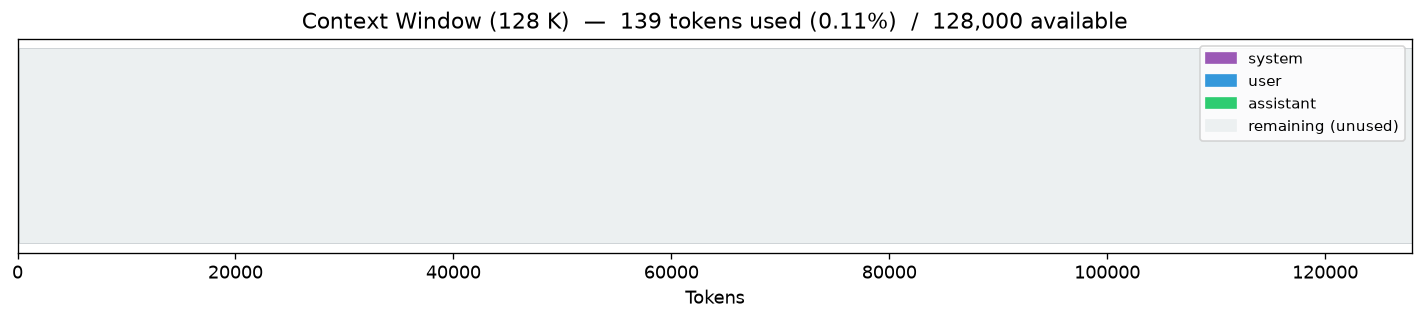

Tokens used: 139
Tokens remaining: 127,861
Est. input cost (gpt-5.4-mini @ $0.00015/1K): $0.000021


In [10]:
# ── Context-window fill visualisation ────────────────────────────────────────
MAX_CTX = 128_000

conversation = [
    ('system',    'You are a helpful Python tutor for working professionals. Be concise.'),
    ('user',      'What is a list comprehension?'),
    ('assistant', 'A list comprehension builds a list in one line: [x**2 for x in range(10)].'),
    ('user',      'Can you show a more complex example with filtering?'),
    ('assistant', '[x for x in range(1, 101) if x % 3 == 0 and x % 5 == 0] returns multiples of 15.'),
    ('user',      'How does it compare to a regular for-loop in terms of speed and readability?'),
    ('assistant', 'List comprehensions are ~30% faster (CPython bytecode is optimised) and more '
                  'Pythonic for simple transforms. Prefer a for-loop when the body is long or has side effects.'),
]

role_colors = {'system': '#9b59b6', 'user': '#3498db', 'assistant': '#2ecc71'}
cumulative  = 0
segments    = []

for role, text in conversation:
    n = len(enc.encode(text))
    segments.append((role, cumulative, n))
    cumulative += n

fig, ax = plt.subplots(figsize=(12, 2.8))

for role, start, n in segments:
    ax.barh(0, n, left=start, color=role_colors[role],
            edgecolor='white', linewidth=0.7, height=0.55)
    if n > 300:
        ax.text(start + n / 2, 0, f'{role}\n{n} tok',
                ha='center', va='center', fontsize=8, color='white', fontweight='bold')

# Remaining space
ax.barh(0, MAX_CTX - cumulative, left=cumulative,
        color='#ecf0f1', edgecolor='#bdc3c7', linewidth=0.4, height=0.55)

ax.set_xlim(0, MAX_CTX)
ax.set_yticks([])
ax.set_xlabel('Tokens')
used_pct = cumulative / MAX_CTX * 100
ax.set_title(
    f'Context Window (128 K)  —  {cumulative:,} tokens used ({used_pct:.2f}%)  /  {MAX_CTX:,} available'
)

legend_patches = [mpatches.Patch(color=c, label=r) for r, c in role_colors.items()]
legend_patches.append(mpatches.Patch(color='#ecf0f1', label='remaining (unused)'))
ax.legend(handles=legend_patches, loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

print(f'Tokens used: {cumulative:,}')
print(f'Tokens remaining: {MAX_CTX - cumulative:,}')
print(f'Est. input cost (gpt-5.4-mini @ $0.00015/1K): ${cumulative/1000*0.00015:.6f}')

---
## Part 5 — Streaming: Watch the Model Think

By default `create()` waits until the entire response is ready, then returns it.
With `stream=True` the API sends tokens **as they are generated**.

**Why streaming matters:**
- Users see output immediately instead of staring at a blank screen for 5–10 s.
- Latency perceived by the user is *time to first token*, not total generation time.
- Real-time apps (chatbots, dashboards, voice interfaces) are only feasible with streaming.

Below we print each chunk as it arrives and measure tokens per second.

In [11]:
# ── Streaming with per-chunk timing ─────────────────────────────────────────
prompt = 'Explain recursion to a 10-year-old in three short sentences.'

if MOCK or client is None:
    mock_text = (
        'Recursion is when a function calls itself to solve a smaller version of the same problem. '
        'Think of it like Russian nesting dolls — each doll contains a smaller doll inside. '
        'It keeps going until it reaches the tiniest doll (the base case) and then stops.'
    )
    print(f'Prompt: {prompt}\n')
    print('─' * 60)
    for word in mock_text.split():
        print(word + ' ', end='', flush=True)
        time.sleep(0.04)
    print(f'\n{"─" * 60}')
    print('\n  [MOCK] ~46 tokens delivered in simulated stream')
else:
    stream = client.chat.completions.create(
        model=MODEL,
        messages=[{'role': 'user', 'content': prompt}],
        stream=True,
        max_completion_tokens=150,
    )
    print(f'Prompt: {prompt}\n')
    print('─' * 60)
    t0 = time.time()
    token_count = 0

    for chunk in stream:
        delta = chunk.choices[0].delta.content or ''
        if delta:
            print(delta, end='', flush=True)
            token_count += 1

    elapsed = time.time() - t0
    print(f'\n{"─" * 60}')
    print(f'\n  ✓ ~{token_count} chunks in {elapsed:.2f}s  ({token_count/elapsed:.1f} tok/s)')

Prompt: Explain recursion to a 10-year-old in three short sentences.

────────────────────────────────────────────────────────────
Rec

ursion

 is

 when

 a

...

 the

 base

 case

.


────────────────────────────────────────────────────────────

  ✓ ~58 chunks in 0.35s  (163.7 tok/s)


---
## Part 6 — Model Landscape: Cost vs Capability

OpenAI offers a spectrum of models. The key trade-off is **cost vs quality**.

| Model | Best for |
|-------|----------|
| `gpt-5.4-nano` | High-volume, simple tasks — classify, extract, rewrite |
| `gpt-5.4-mini` | General use — **default for this course** |
| `gpt-5.4` | Complex reasoning, professional-grade long-form output |
| `gpt-5.5` | Best available quality; use sparingly (3× more expensive) |
| `gpt-5.5-pro` | Frontier research / expert-level tasks |

> Prices below are approximate for June 2026. Always verify at [openai.com/pricing](https://openai.com/pricing).

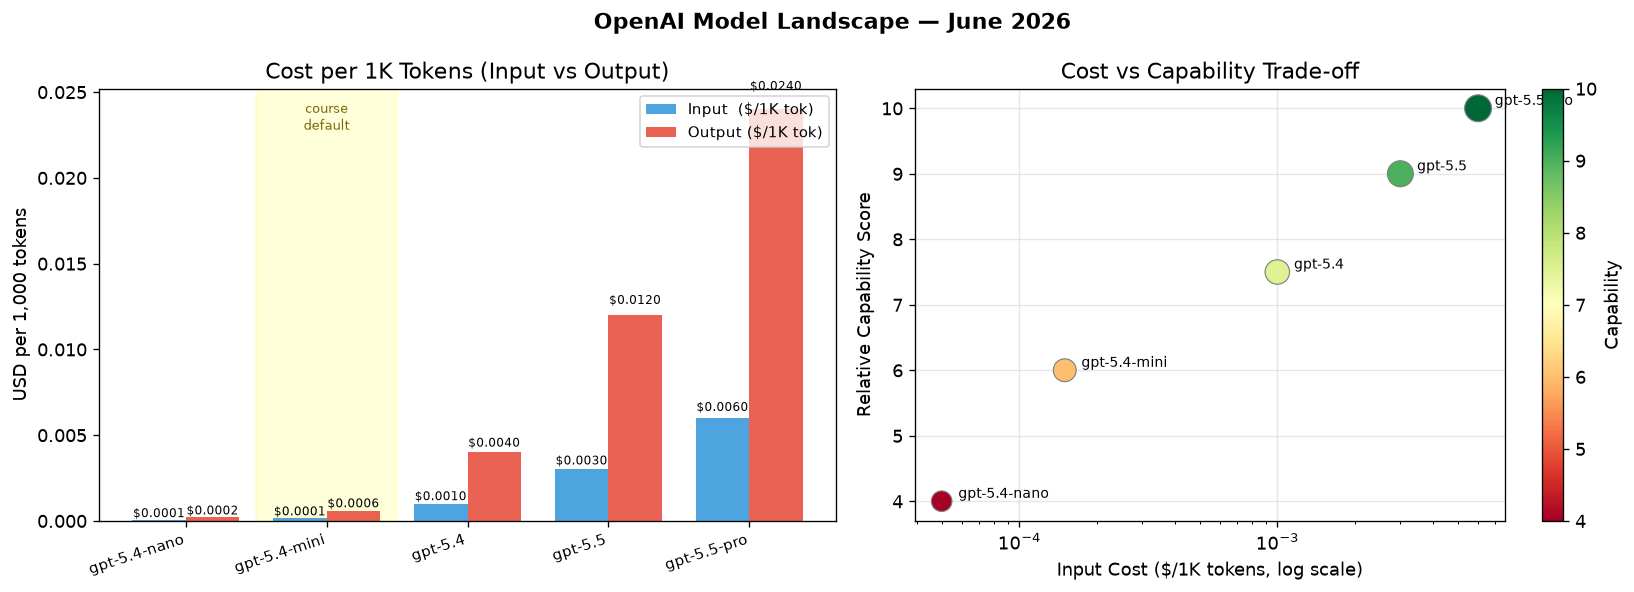

Cost to send 1 million input tokens with each model:
  gpt-5.4-nano        $   0.05
  gpt-5.4-mini        $   0.15
  gpt-5.4             $   1.00
  gpt-5.5             $   3.00
  gpt-5.5-pro         $   6.00


In [12]:
# ── Model cost & capability landscape ────────────────────────────────────────
model_names  = ['gpt-5.4-nano', 'gpt-5.4-mini', 'gpt-5.4', 'gpt-5.5', 'gpt-5.5-pro']
input_costs  = [0.00005, 0.00015, 0.00100, 0.00300, 0.00600]   # $ per 1K tokens
output_costs = [0.00020, 0.00060, 0.00400, 0.01200, 0.02400]
capability   = [4, 6, 7.5, 9, 10]                               # relative, illustrative

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: grouped bar — input vs output cost ──────────────────────────────────
x = np.arange(len(model_names))
w = 0.38
b1 = ax1.bar(x - w/2, input_costs,  w, label='Input  ($/1K tok)', color='#3498db', alpha=0.88)
b2 = ax1.bar(x + w/2, output_costs, w, label='Output ($/1K tok)', color='#e74c3c', alpha=0.88)

for bar in [*b1, *b2]:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, h * 1.04,
             f'${h:.4f}', ha='center', va='bottom', fontsize=7)

ax1.set_xticks(x)
ax1.set_xticklabels(model_names, rotation=18, ha='right', fontsize=9)
ax1.set_ylabel('USD per 1,000 tokens')
ax1.set_title('Cost per 1K Tokens (Input vs Output)')
ax1.legend(fontsize=9)
# Highlight the course default
ax1.axvspan(0.5, 1.5, color='yellow', alpha=0.15, zorder=0)
ax1.text(1, max(output_costs) * 0.95, 'course\ndefault', ha='center', fontsize=8, color='#7d6608')

# ── Right: cost vs capability scatter ────────────────────────────────────────
scatter = ax2.scatter(
    input_costs, capability,
    s=[80 + c * 18 for c in capability],
    c=capability, cmap='RdYlGn', zorder=5,
    edgecolors='gray', linewidths=0.7,
)
for i, name in enumerate(model_names):
    ax2.annotate(name, (input_costs[i], capability[i]),
                 textcoords='offset points', xytext=(10, 2), fontsize=8.5)

ax2.set_xscale('log')
ax2.set_xlabel('Input Cost ($/1K tokens, log scale)')
ax2.set_ylabel('Relative Capability Score')
ax2.set_title('Cost vs Capability Trade-off')
ax2.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax2, label='Capability')

fig.suptitle('OpenAI Model Landscape — June 2026', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Cost sanity check: 1 million input tokens ─────────────────────────────────
print('Cost to send 1 million input tokens with each model:')
for name, ic in zip(model_names, input_costs):
    print(f'  {name:<18}  ${ic * 1000:>7.2f}')

---
## Bonus — The Generation Loop Visualised

The diagram below summarises everything we have covered.
Each step is one iteration of the **decode loop** inside the model.

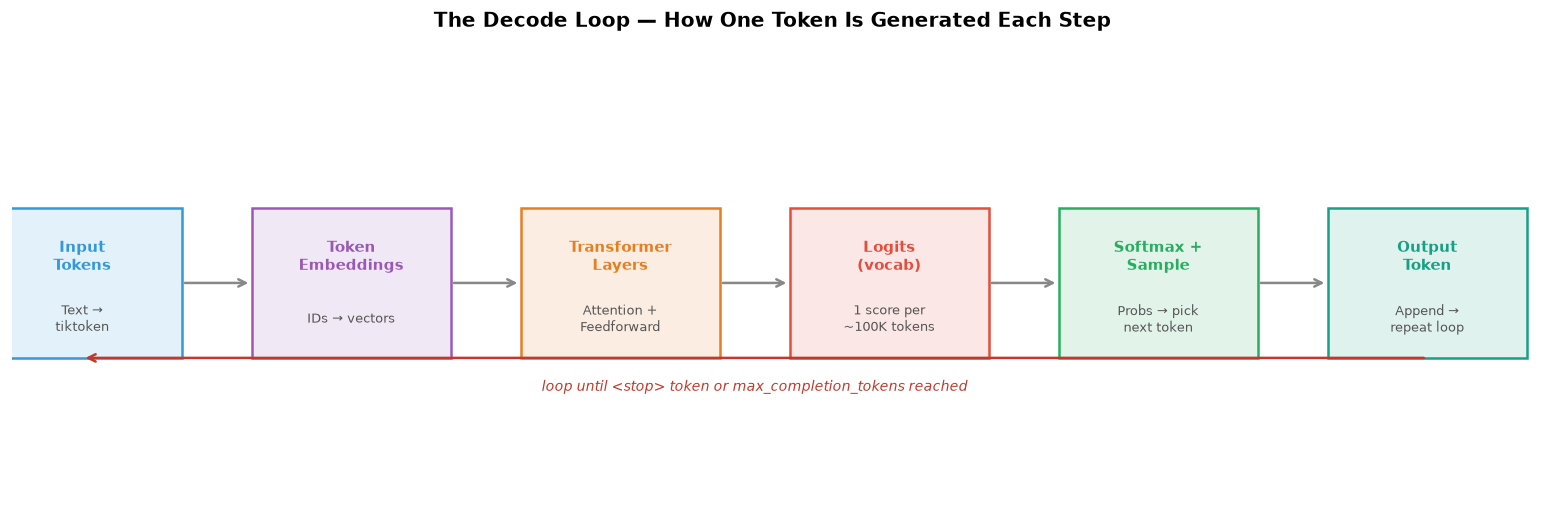

In [13]:
# ── Generation-loop diagram using matplotlib ─────────────────────────────────
import matplotlib.patches as FancyBboxPatch

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.set_xlim(0, 13); ax.set_ylim(0, 4.5)
ax.axis('off')

steps = [
    (0.6,  2.2, '#3498db', 'Input\nTokens',     'Text →\ntiktoken'),
    (2.9,  2.2, '#9b59b6', 'Token\nEmbeddings', 'IDs → vectors'),
    (5.2,  2.2, '#e67e22', 'Transformer\nLayers', 'Attention +\nFeedforward'),
    (7.5,  2.2, '#e74c3c', 'Logits\n(vocab)',    '1 score per\n~100K tokens'),
    (9.8,  2.2, '#27ae60', 'Softmax +\nSample',  'Probs → pick\nnext token'),
    (12.1, 2.2, '#16a085', 'Output\nToken',      'Append →\nrepeat loop'),
]

for x, y, color, label, sublabel in steps:
    box = plt.Rectangle((x - 0.85, y - 0.72), 1.7, 1.44,
                         linewidth=1.5, edgecolor=color, facecolor=color + '22',
                         transform=ax.transData, zorder=2)
    ax.add_patch(box)
    ax.text(x, y + 0.25, label, ha='center', va='center',
            fontsize=9, fontweight='bold', color=color, zorder=3)
    ax.text(x, y - 0.35, sublabel, ha='center', va='center',
            fontsize=7.5, color='#555', zorder=3)

# Arrows between boxes
for i in range(len(steps) - 1):
    x1 = steps[i][0] + 0.85
    x2 = steps[i+1][0] - 0.85
    y  = steps[i][1]
    ax.annotate('', xy=(x2, y), xytext=(x1, y),
                arrowprops=dict(arrowstyle='->', color='#888', lw=1.5))

# Loop-back arrow for "repeat"
ax.annotate('', xy=(0.6, 1.48), xytext=(12.1, 1.48),
            arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.5,
                            connectionstyle='arc3,rad=0'))
ax.text(6.35, 1.2, 'loop until <stop> token or max_completion_tokens reached',
        ha='center', va='center', fontsize=8.5, color='#c0392b', style='italic')

ax.set_title('The Decode Loop — How One Token Is Generated Each Step',
             fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

---
## Common Pitfalls

| Error | Likely Cause | Fix |
|-------|-------------|-----|
| `AuthenticationError` | Missing or invalid API key | Check `.env`, confirm key starts with `sk-` |
| `RateLimitError` | Too many requests or monthly cap reached | Wait 60 s; check billing dashboard |
| `model not found` | Typo in model string | Always use `MODELS['chat']` from `utils/config.py` |
| Logprobs always `None` | Forgot `logprobs=True` in request | Add parameter to `create()` |
| Tokens much higher than expected | System prompt is large / history growing | Print `response.usage` to inspect |
| Output truncated | `max_tokens` too low | Increase or remove `max_tokens` |

---
## Recap

- **Tokens** are the atomic unit. English ≈ 4 chars/token; non-Latin scripts use more → higher cost per word.
- An LLM outputs a **probability distribution** over its vocabulary; sampling from it gives the next token.
- **Temperature** shapes that distribution — low = focused/deterministic, high = creative/random.
- The **context window** holds system prompt + conversation history + new turn + completion, all billed as tokens.
- **Streaming** delivers tokens as they are generated — essential for real-time UX.
- **Model choice** is a cost-vs-quality trade-off; default to `gpt-5.4-mini` throughout this course.

---
## Before Session 1 (Sat 20 Jun)

1. **Setup:** Complete the `README.md` steps — install packages, add your API key to `.env`, run the setup cell in `01_foundations.ipynb`.
2. **Explore:** Run `show_tokens()` on a paragraph from your last work email. How many tokens? What would it cost to send it 1 000 times with `gpt-5.4-mini`?
3. **Think:** If you send a 10-message chat history (~500 prompt tokens) to `gpt-5.4-mini` and receive 200 completion tokens, what is the estimated cost? (Use the pricing table in Part 6.)
4. **Read:** Browse the [Chat Completions quickstart](https://platform.openai.com/docs/guides/chat-completions) on the OpenAI docs.

> *Answers in Session 1!*